# GARCÍA HERNÁNDEZ RODRIGO | 23070447
# ANÁLISIS DE SENTIMIENTOS PT 2 

# ANALISIS DE SENTIMIENTOS CON X 
Usando los data sets de BilliGates, ElonMusk y MayorLee. Haga lo siguiente:
Se tiene un conjunto de datos de tres personas donde dos de ellos tienen oficios en común, y la tercera persona se enfoca en otra actividad. Sin embargo, el objetivo de la práctica es hacer un análisis de datos en función de lo que comparten en su red social como es X.
Para este trabajo se hará un análisis de sentimientos de la información que comparten los participantes usando un enfoque Basado en Lexicón, que es una de las metodologías más utilizadas para el análisis de sentimientos. Consiste en utilizar un diccionario o léxico donde cada palabra o frase tiene asignada una puntuación de polaridad (positiva, negativa o neutra), y a partir de esas puntuaciones se calcula el sentimiento global de un texto. 
El enfoque basado en léxico es rápido, interpretable y fácil de implementar, lo que lo hace ideal para prototipos, análisis exploratorios y aplicaciones en tiempo real. Sin embargo, su falta de contexto y su dificultad para manejar ironía, sarcasmo y dominios específicos limitan su precisión. Por ello, en proyectos que requieren alta exactitud, suele combinarse con técnicas de machine learning o deep learning, o utilizarse como una primera capa de análisis.
Entonces aplicando la metodología revisada y los ejemplos de la clase hacer lo siguiente:

* Cargar las librerías
* Cargar los datos
* Limpieza del texto, tokenización y eliminación de stopwords.
* Análisis Exploratorio
* Distribución temporal de los tweets.
* Frecuencia de las palabras, en primer lugar, en total cuantas usa cada usuario.
* Palabras distintas que usa cada usuario
* Palabras más utilizadas por usuario
* Longitud media de los twees por usuario
* Haga graficas para todos los puntos anteriores
* Hacer Word clouds de las palabras distintas que usa cada usuario.
* Análisis de Sentimientos
* Sentimiento promedio de cada tweet
* Porcentajes de tweets positivos, negativos y neutros
* Evolución de los sentimientos en función del tiempo.
* Todos los análisis deben ser soportados con gráficas.
* Finalmente escriba su conclusión del análisis tomando en cuenta todo los análisis realizados.



# 1. Cargar las librerias

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer


nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('vader_lexicon')


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /usr/share/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

# 2. Cargar los datos


In [6]:
import pandas as pd
dGates = pd.read_csv('/kaggle/input/datasets/rodrigogarciah/datosbillgates/datos_tweets_BillGates.csv')

print(dGates)

     screen_name   user_id            created_at     status_id  \
0      BillGates  50393960  2017-11-09T20:09:06Z  9.287161e+17   
1      BillGates  50393960  2017-11-08T16:39:30Z  9.283010e+17   
2      BillGates  50393960  2017-11-07T17:43:05Z  9.279546e+17   
3      BillGates  50393960  2017-11-02T17:42:19Z  9.261424e+17   
4      BillGates  50393960  2017-10-30T04:01:05Z  9.248486e+17   
...          ...       ...                   ...           ...   
2082   BillGates  50393960  2011-10-19T22:12:21Z  1.267828e+17   
2083   BillGates  50393960  2011-10-06T00:38:09Z  1.217460e+17   
2084   BillGates  50393960  2011-10-06T00:37:29Z  1.217459e+17   
2085   BillGates  50393960  2011-10-04T19:06:05Z  1.213001e+17   
2086   BillGates  50393960  2011-09-29T21:11:15Z  1.195196e+17   

                                                   text  retweet_count  \
0     Tanzania hopes to eliminate one of the world’s...            608   
1     By investing in R&amp;D, I know we can discove...    

In [7]:
import pandas as pd
dMusk = pd.read_csv('/kaggle/input/datasets/rodrigogarciah/datoselonmusk/datos_tweets_elonmusk.csv')

print(dMusk)

     screen_name   user_id            created_at     status_id  \
0       elonmusk  44196397  2017-11-09T17:28:57Z  9.286758e+17   
1       elonmusk  44196397  2017-11-09T17:12:46Z  9.286717e+17   
2       elonmusk  44196397  2017-11-08T18:55:13Z  9.283351e+17   
3       elonmusk  44196397  2017-11-07T19:48:45Z  9.279862e+17   
4       elonmusk  44196397  2017-10-28T21:36:18Z  9.243894e+17   
...          ...       ...                   ...           ...   
2673    elonmusk  44196397  2013-03-20T00:53:40Z  3.141779e+17   
2674    elonmusk  44196397  2013-03-19T03:03:05Z  3.138481e+17   
2675    elonmusk  44196397  2013-03-17T18:32:54Z  3.133573e+17   
2676    elonmusk  44196397  2013-03-17T18:20:24Z  3.133541e+17   
2677    elonmusk  44196397  2013-03-10T00:39:02Z  3.105503e+17   

                                                   text  retweet_count  \
0     "If one day, my words are against science, cho...          49919   
1     I placed the flowers\n\nThree broken ribs\nA p...    

In [8]:
import pandas as pd
dLee = pd.read_csv('/kaggle/input/datasets/rodrigogarciah/datosmayoredlee/datos_tweets_mayoredlee.csv')

print(dLee)

     screen_name    user_id            created_at     status_id  \
0     mayoredlee  234489403  2017-11-09T22:50:42Z  9.287568e+17   
1     mayoredlee  234489403  2017-11-09T19:27:42Z  9.287057e+17   
2     mayoredlee  234489403  2017-11-09T19:00:05Z  9.286987e+17   
3     mayoredlee  234489403  2017-11-09T18:59:04Z  9.286985e+17   
4     mayoredlee  234489403  2017-11-09T01:19:25Z  9.284318e+17   
...          ...        ...                   ...           ...   
2442  mayoredlee  234489403  2015-06-21T17:38:40Z  6.126760e+17   
2443  mayoredlee  234489403  2015-06-20T23:17:06Z  6.123988e+17   
2444  mayoredlee  234489403  2015-06-20T17:54:32Z  6.123176e+17   
2445  mayoredlee  234489403  2015-06-20T14:42:22Z  6.122693e+17   
2446  mayoredlee  234489403  2015-06-20T05:50:19Z  6.121354e+17   

                                                   text  retweet_count  \
0     Thank you to all the dedicated City employees ...              1   
1     .@JeffSheehySF and I took to the streets 

In [9]:
dGates = pd.read_csv("/kaggle/input/datasets/rodrigogarciah/datosbillgates/datos_tweets_BillGates.csv")
dMusk = pd.read_csv("/kaggle/input/datasets/rodrigogarciah/datoselonmusk/datos_tweets_elonmusk.csv")
dLee = pd.read_csv("/kaggle/input/datasets/rodrigogarciah/datosmayoredlee/datos_tweets_mayoredlee.csv")

print(f"dGates cargado exitosamente: {dGates.shape}")
print(f"dMusk cargado exitosamente:  {dMusk.shape}")
print(f"dLee cargado exitosamente:   {dLee.shape}")

dGates cargado exitosamente: (2087, 35)
dMusk cargado exitosamente:  (2678, 35)
dLee cargado exitosamente:   (2447, 35)


In [13]:
df = pd.concat([dGates, dMusk, dLee], ignore_index=True)
print(df.shape)

(7212, 35)


# 3. Limpieza de texto, tokenización y stopwords

limpieza con regex


In [14]:
import re

def clean_text(text):
    text = str(text).lower() 
    text = re.sub(r'http\S+', '', text)
    regex = r'[\!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~]'
    text = re.sub(regex, '', text)
    
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'@[A-Za-z0-9_]+', '', text) 
    text = re.sub(r'#[A-Za-z0-9_]+', '', text) 
    text = re.sub(r'[^a-zA-Z\s]', '', text) 
    text = re.sub(r'\s+', ' ', text).strip() 
    return text

df['Clean_Content'] = df['text'].apply(clean_text)
df = df[df['Clean_Content'] != ''].copy() 

for d in [dGates, dMusk, dLee]:
    d['Clean_Content'] = d['text'].apply(clean_text)
    d.drop(d[d['Clean_Content'] == ''].index, inplace=True)

display(df[['text', 'Clean_Content']].sample(10))

,text,Clean_Content
5470,Our investment in the @SoMaPilipinas Cultural ...,our investment in the cultural heritage distri...
519,Melinda and I recently spent a day in New York...,melinda and i recently spent a day in new york...
4180,West Coast droneship under construction will b...,west coast droneship under construction will b...
1420,I got to wear a new hat today: magazine editor...,i got to wear a new hat today magazine editor ...
3219,@MacTechGenius I personally like the 6 seat be...,i personally like the seat best but the new al...
4136,SolarCity systems generated a new daily record...,solarcity systems generated a new daily record...
5422,We're increasing funding to expand pretrial di...,were increasing funding to expand pretrial div...
2711,@waitbutwhy Heisenberg's uncertainty principle...,heisenbergs uncertainty principle amp practica...
2214,Putting together SpaceX rocket landing blooper...,putting together spacex rocket landing blooper...
2472,@newscientist Exactly,exactly


tokenización y filtrado de stopwords


In [15]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def tokenizacion(text):
    tokens = word_tokenize(text) 
    return tokens

def preprocess_tokens(text):
    tokens = word_tokenize(text) 
    filtered = [w for w in tokens if w not in stop_words] 
    return " ".join(filtered) 

for name, d in [('Bill Gates', dGates), ('Elon Musk', dMusk), ('Mayor Ed Lee', dLee)]:
    d['texto_tokenizado'] = d['Clean_Content'].apply(tokenizacion)
    d['Final_Content'] = d['Clean_Content'].apply(preprocess_tokens)
    print(name)

    
    display(d[['Clean_Content', 'texto_tokenizado', 'Final_Content']].sample(10))

Bill Gates


,Clean_Content,texto_tokenizado,Final_Content
47,im very disappointed with todays decision to e...,"[im, very, disappointed, with, todays, decisio...",im disappointed todays decision end statement
440,there is no shortage of books about japans eco...,"[there, is, no, shortage, of, books, about, ja...",shortage books japans economy one great place ...
1714,we have an opportunity to accelerate progress ...,"[we, have, an, opportunity, to, accelerate, pr...",opportunity accelerate progress poverty hunger...
805,should we eat meat this book i recently read o...,"[should, we, eat, meat, this, book, i, recentl...",eat meat book recently read offers great food ...
533,our experience working together has transforme...,"[our, experience, working, together, has, tran...",experience working together transformed contin...
1340,in people thought s trials were wacky but toda...,"[in, people, thought, s, trials, were, wacky, ...",people thought trials wacky today transforming...
1345,its a shame that extreme views get so much att...,"[its, a, shame, that, extreme, views, get, so,...",shame extreme views get much attention bet pro...
1493,version of my latest book review q how much of...,"[version, of, my, latest, book, review, q, how...",version latest book review q much use every year
39,i recently had lunch with a class of primary s...,"[i, recently, had, lunch, with, a, class, of, ...",recently lunch class primary school students t...
1108,brrr i dumped ice water on my head to raise aw...,"[brrr, i, dumped, ice, water, on, my, head, to...",brrr dumped ice water head raise awareness als


Elon Musk


,Clean_Content,texto_tokenizado,Final_Content
411,we used to have a lame open loop hydraulic sys...,"[we, used, to, have, a, lame, open, loop, hydr...",used lame open loop hydraulic system upgraded ...
1571,yes,[yes],yes
948,yes,[yes],yes
1739,af has placed launch on hold due to a boat ent...,"[af, has, placed, launch, on, hold, due, to, a...",af placed launch hold due boat entering edge k...
589,will shut that down the point is to provide so...,"[will, shut, that, down, the, point, is, to, p...",shut point provide something special existing ...
1112,both uv and ir for heat reflective i burn easi...,"[both, uv, and, ir, for, heat, reflective, i, ...",uv ir heat reflective burn easily amp nose loo...
2003,wow,[wow],wow
1019,all satellites deployed,"[all, satellites, deployed]",satellites deployed
2541,tesla priority is electrification of cars so p...,"[tesla, priority, is, electrification, of, car...",tesla priority electrification cars priority m...
817,will send you one,"[will, send, you, one]",send one


Mayor Ed Lee


,Clean_Content,texto_tokenizado,Final_Content
2331,today amp every day remembers amp honors lives...,"[today, amp, every, day, remembers, amp, honor...",today amp every day remembers amp honors lives...
1919,rooting for on amp off court for leadership in...,"[rooting, for, on, amp, off, court, for, leade...",rooting amp court leadership creating opportun...
1462,in partnership w weve connected thousands of y...,"[in, partnership, w, weve, connected, thousand...",partnership w weve connected thousands youth j...
908,sweet taste of victory,"[sweet, taste, of, victory]",sweet taste victory
2186,city hall lit in red for to remember lives los...,"[city, hall, lit, in, red, for, to, remember, ...",city hall lit red remember lives lost amp reco...
1411,dr martin luther king jrs legacy is a reminder...,"[dr, martin, luther, king, jrs, legacy, is, a,...",dr martin luther king jrs legacy reminder righ...
1001,our ambitious goals have steered toward a more...,"[our, ambitious, goals, have, steered, toward,...",ambitious goals steered toward green amp susta...
1677,rose pak battled on behalf of the poor of immi...,"[rose, pak, battled, on, behalf, of, the, poor...",rose pak battled behalf poor immigrants women ...
606,mayors across the country are asking g leaders...,"[mayors, across, the, country, are, asking, g,...",mayors across country asking g leaders take st...
1944,s favorite superhero is who saved gotham city ...,"[s, favorite, superhero, is, who, saved, gotha...",favorite superhero saved gotham city amp earne...


# 4. Análisis explotatorio

# 4.1 Distribución temporal de los tweets

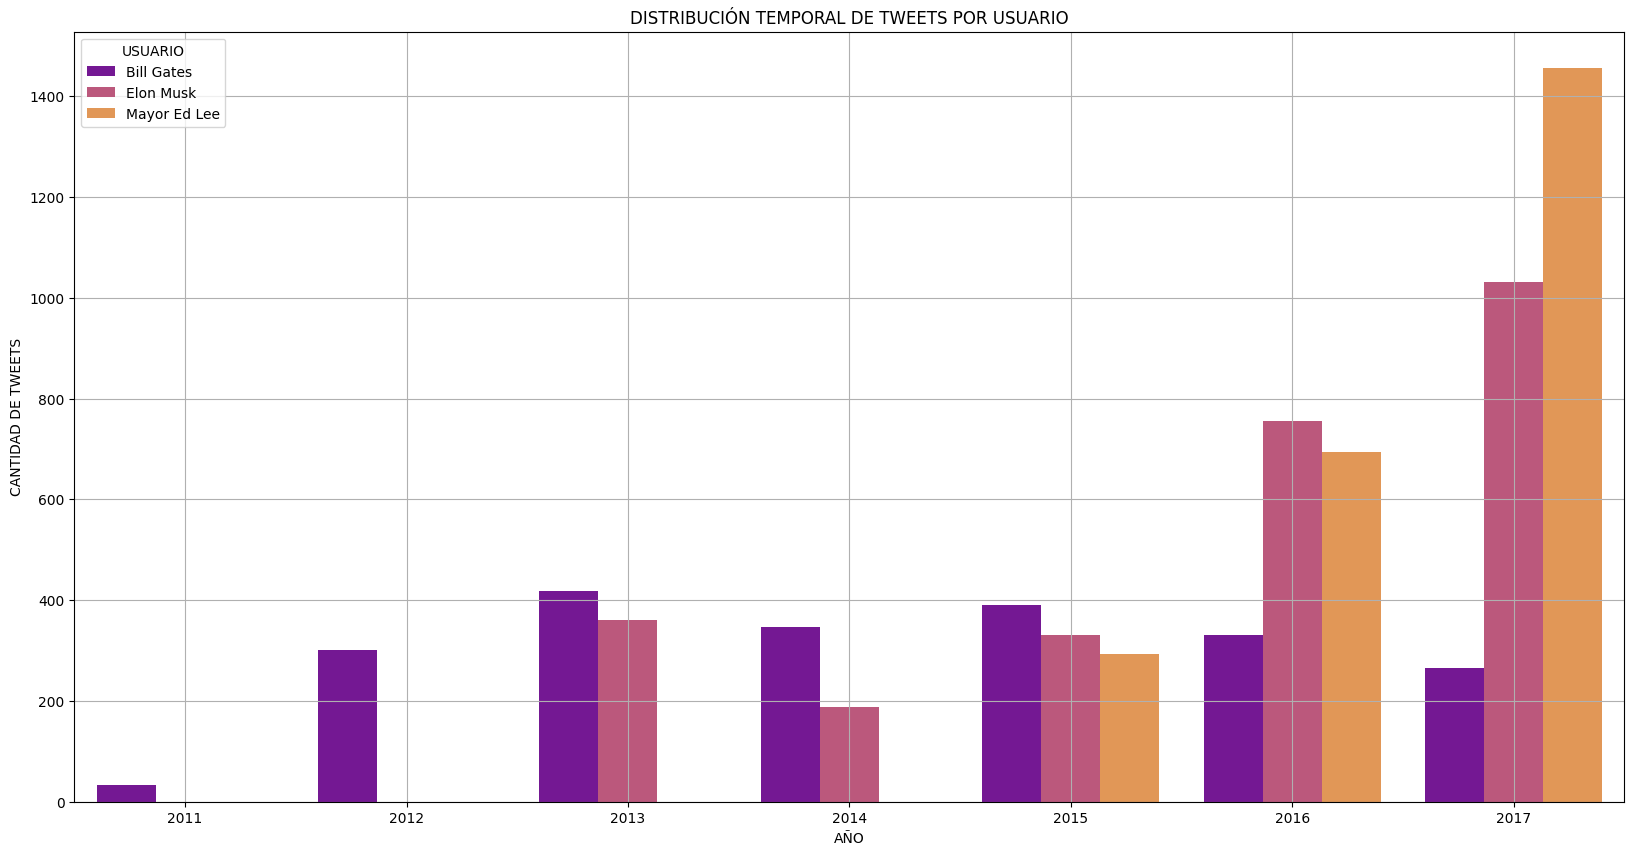

In [16]:
for df_user in [dGates, dMusk, dLee]:
    df_user['created_at'] = pd.to_datetime(df_user['created_at'])
    df_user['year'] = df_user['created_at'].dt.year

df_temporal = pd.concat([
    dGates[['year']].assign(Usuario='Bill Gates'),
    dMusk[['year']].assign(Usuario='Elon Musk'),
    dLee[['year']].assign(Usuario='Mayor Ed Lee')
])

plt.figure(figsize=(20, 10))
sns.countplot(data=df_temporal, x='year', hue='Usuario', palette="plasma")
plt.title("DISTRIBUCIÓN TEMPORAL DE TWEETS POR USUARIO")
plt.xlabel("AÑO")
plt.ylabel("CANTIDAD DE TWEETS")
plt.legend(title="USUARIO")
plt.grid(True)
plt.show()

# 4.2 TOTAL DE CUANTAS PALABRAS USA CADA USUARIO

Total de palabras usadas por usuario


,Usuario,totalPalabras
0,Bill Gates,31063
1,Elon Musk,32444
2,Mayor Ed Lee,38690


/tmp/ipykernel_47/2024544334.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barras = sns.barplot(data=df_total_palabras, x="Usuario", y="totalPalabras", palette="plasma")


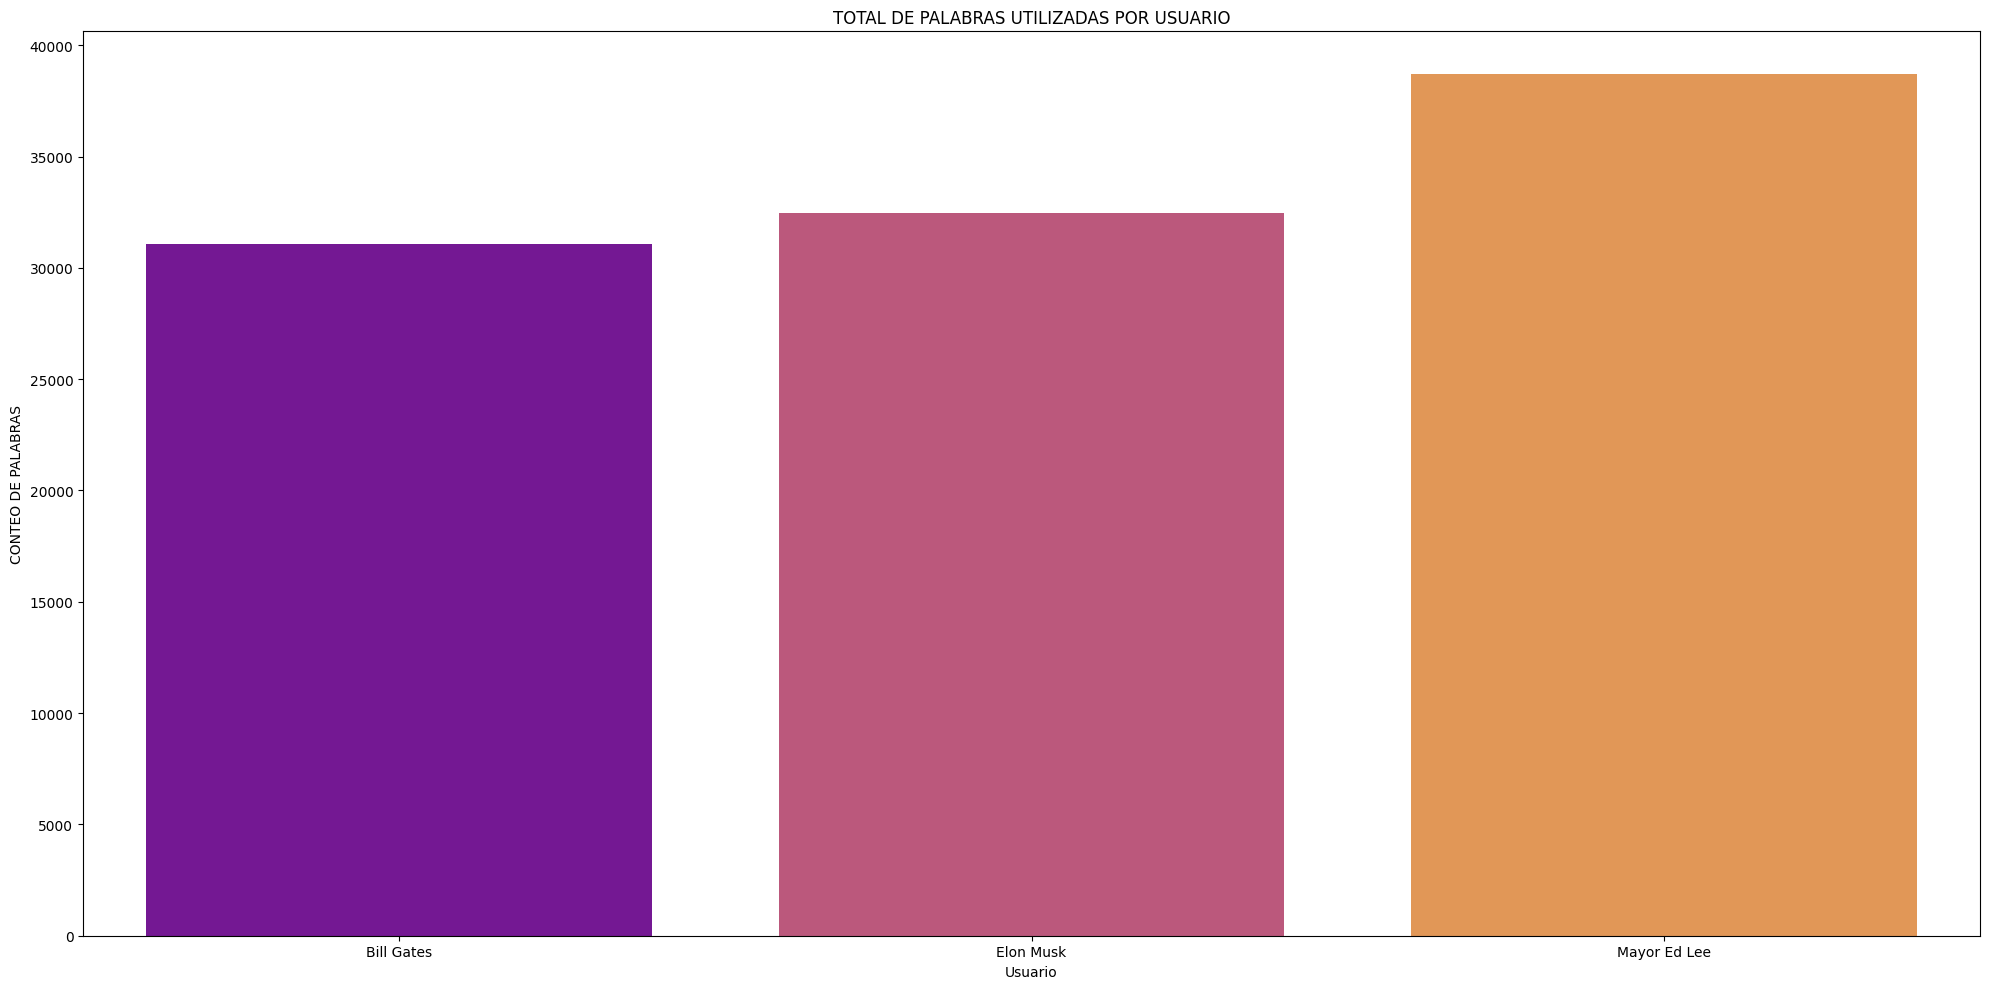

In [17]:
total_palabras_token = {
    "Bill Gates": sum(len(tokens) for tokens in dGates["texto_tokenizado"]),
    "Elon Musk": sum(len(tokens) for tokens in dMusk["texto_tokenizado"]),
    "Mayor Ed Lee": sum(len(tokens) for tokens in dLee["texto_tokenizado"])
}

df_total_palabras = pd.DataFrame(list(total_palabras_token.items()), columns=["Usuario", "totalPalabras"])

print("Total de palabras usadas por usuario")
display(df_total_palabras)

plt.figure(figsize=(20, 10))
barras = sns.barplot(data=df_total_palabras, x="Usuario", y="totalPalabras", palette="plasma")

plt.title("TOTAL DE PALABRAS UTILIZADAS POR USUARIO")
plt.xlabel("Usuario")
plt.ylabel("CONTEO DE PALABRAS")

plt.tight_layout()
plt.show()

# 4.3 PALABRAS DISTINTAS QUE USA CADA USUARIO

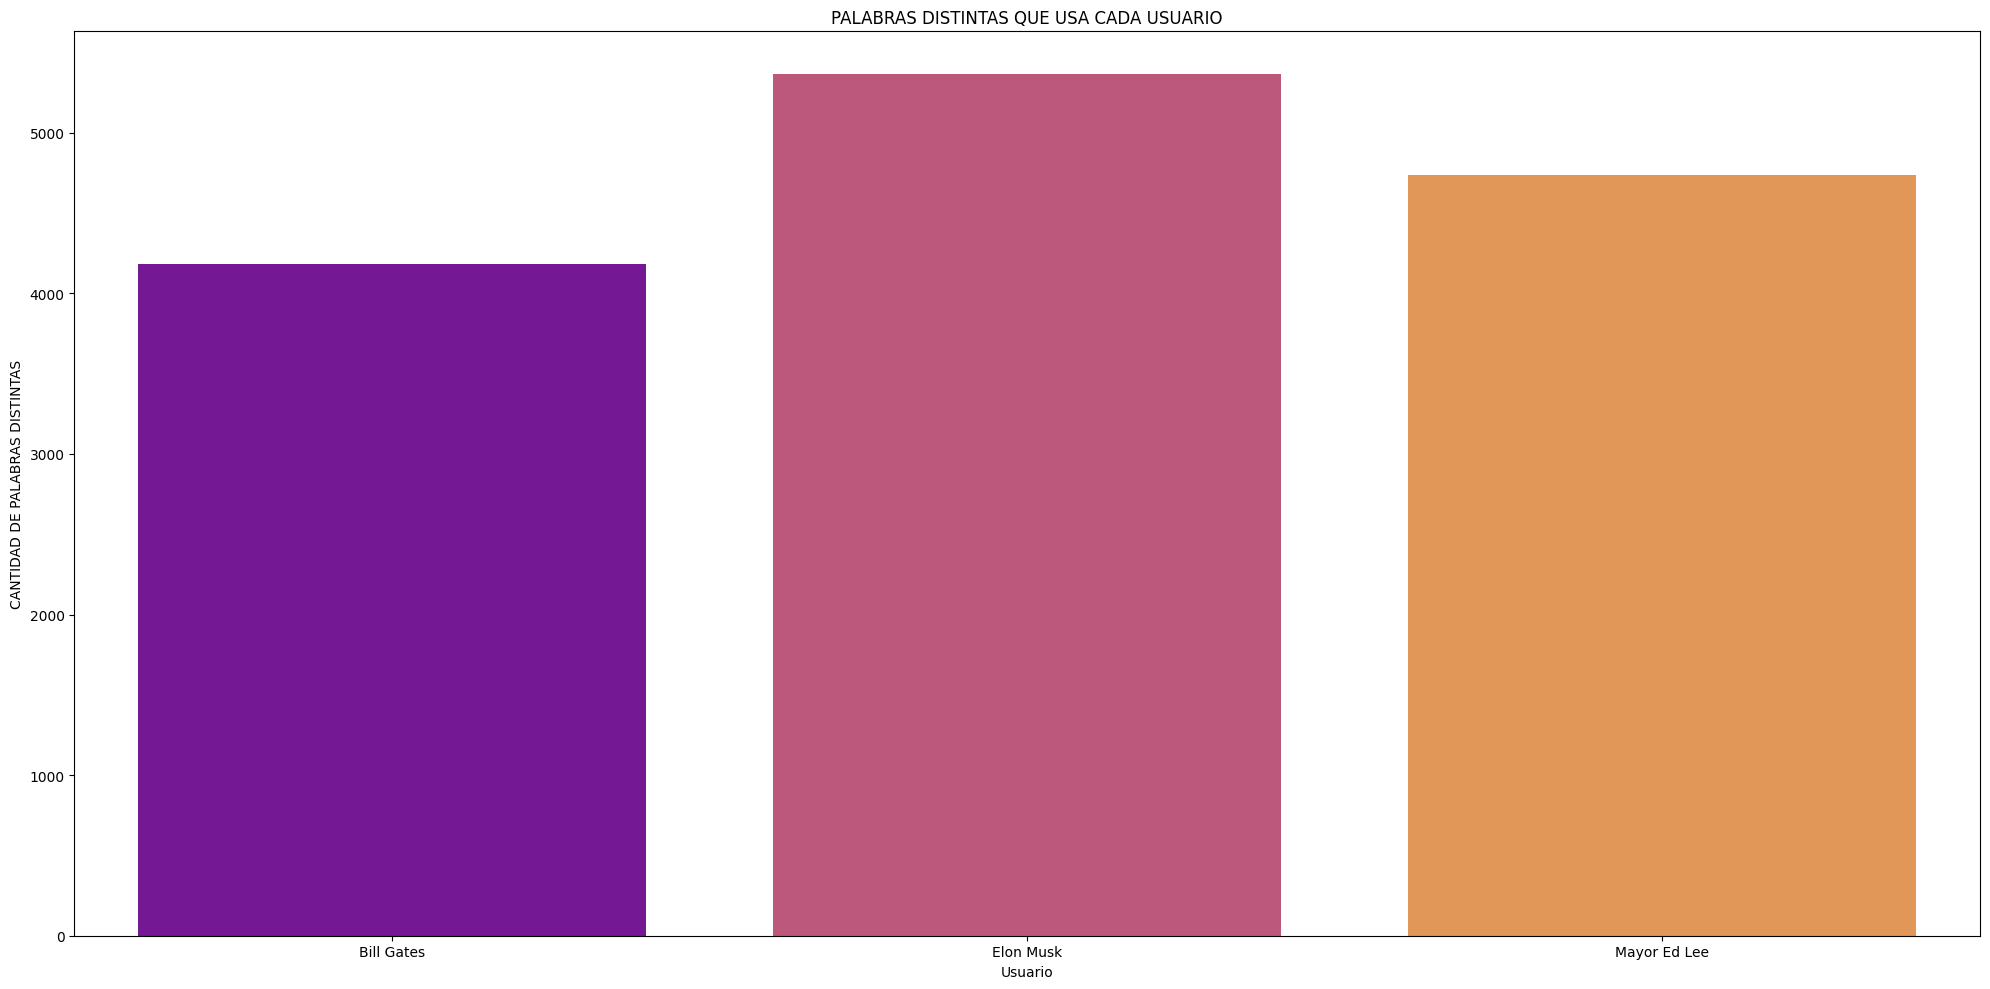

In [19]:
palabras_distintas = {
    "Bill Gates": len(set(w for tokens in dGates["texto_tokenizado"] for w in tokens)),
    "Elon Musk": len(set(w for tokens in dMusk["texto_tokenizado"] for w in tokens)),
    "Mayor Ed Lee": len(set(w for tokens in dLee["texto_tokenizado"] for w in tokens))
}

df_palabras_distintas = pd.DataFrame(list(palabras_distintas.items()), columns=["Usuario", "Palabras distintas"])

plt.figure(figsize=(20, 10))
barras = sns.barplot(data=df_palabras_distintas, x="Usuario", y="Palabras distintas", hue="Usuario",  palette="plasma")
plt.title("PALABRAS DISTINTAS QUE USA CADA USUARIO")
plt.xlabel("Usuario")
plt.ylabel("CANTIDAD DE PALABRAS DISTINTAS")

plt.tight_layout()
plt.show()

# 4.4 PALABRAS MAS UTILIZADAS POR CADA USUARIO

Top 10 - Bill Gates:


,Palabra,Frecuencia
0,great,216
1,one,141
2,people,139
3,world,130
4,new,120


Top 10 - Elon Musk:


,Palabra,Frecuencia
0,tesla,251
1,amp,166
2,model,163
3,good,146
4,yes,119


Top 10 - Ed Lee:


,Palabra,Frecuencia
0,amp,1210
1,city,319
2,residents,268
3,housing,176
4,community,159


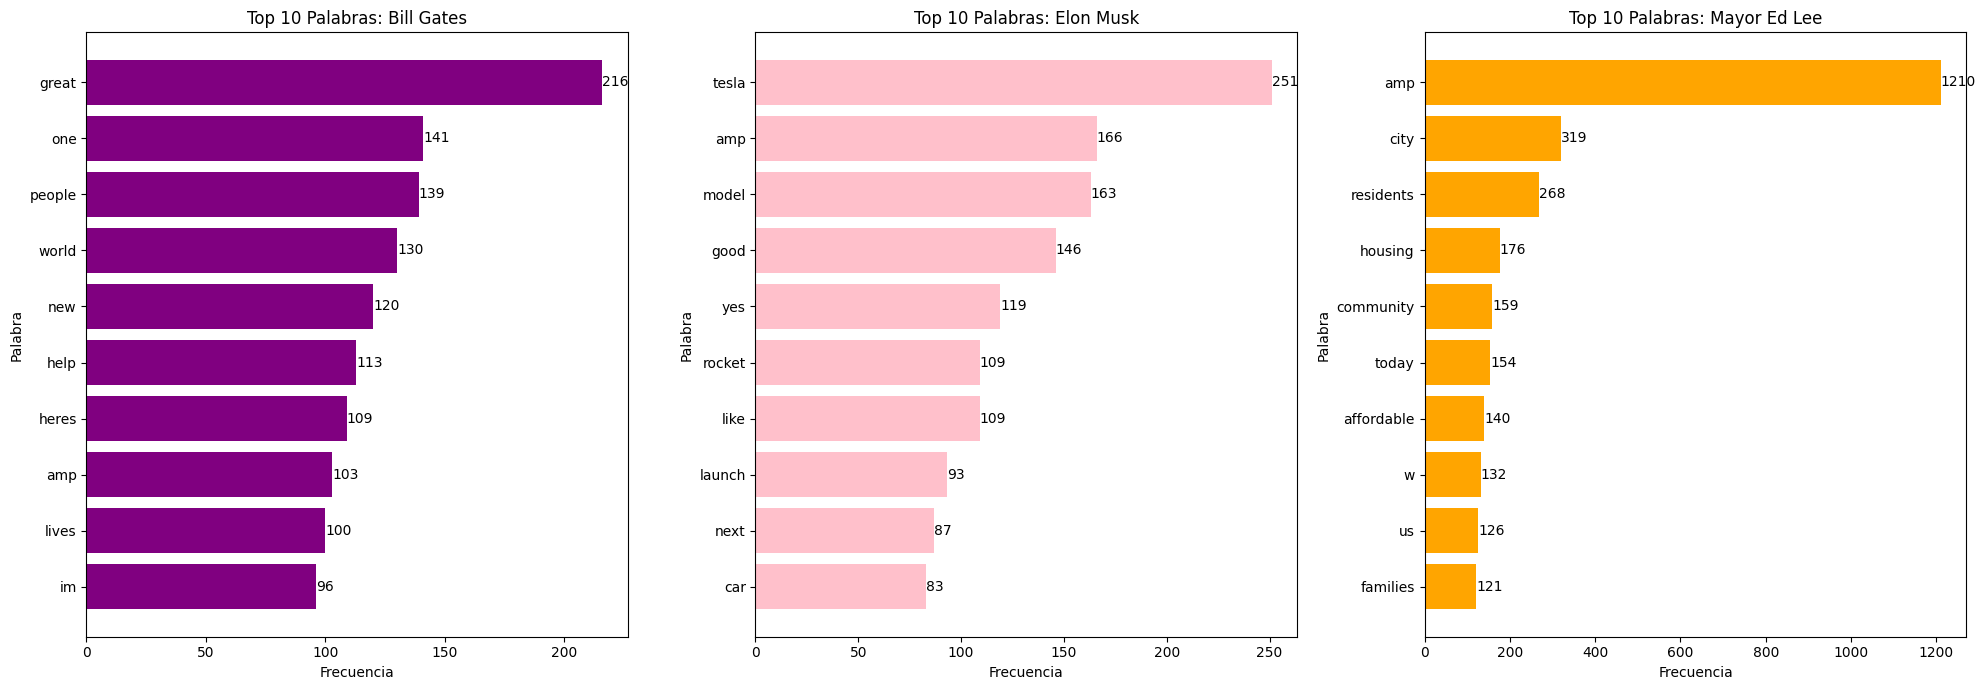

In [20]:
from collections import Counter

def obtener_top_palabras_filtradas(content_series, top_n=10):
    todas_las_palabras = [palabra for texto in content_series for palabra in str(texto).split()]
    comun = Counter(todas_las_palabras).most_common(top_n)
    return pd.DataFrame(comun, columns=["Palabra", "Frecuencia"])

top_gates = obtener_top_palabras_filtradas(dGates["Final_Content"])
top_musk = obtener_top_palabras_filtradas(dMusk["Final_Content"])
top_lee = obtener_top_palabras_filtradas(dLee["Final_Content"])

print("Top 10 - Bill Gates:")
display(top_gates.head(5))

print("Top 10 - Elon Musk:")
display(top_musk.head(5))

print("Top 10 - Ed Lee:")
display(top_lee.head(5))

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

barras_gates = axes[0].barh(top_gates["Palabra"], top_gates["Frecuencia"], color="purple")
axes[0].set_title("Top 10 Palabras: Bill Gates")
axes[0].set_xlabel("Frecuencia")
axes[0].set_ylabel("Palabra")
axes[0].bar_label(barras_gates)
axes[0].invert_yaxis()

barras_musk = axes[1].barh(top_musk["Palabra"], top_musk["Frecuencia"], color="pink")
axes[1].set_title("Top 10 Palabras: Elon Musk")
axes[1].set_xlabel("Frecuencia")
axes[1].set_ylabel("Palabra")
axes[1].bar_label(barras_musk)
axes[1].invert_yaxis()

barras_lee = axes[2].barh(top_lee["Palabra"], top_lee["Frecuencia"], color="orange")
axes[2].set_title("Top 10 Palabras: Mayor Ed Lee")
axes[2].set_xlabel("Frecuencia")
axes[2].set_ylabel("Palabra")
axes[2].bar_label(barras_lee)
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

# 4.5 LONGITUD MEDIA DE LOS TWEETS

Longitud media de los tweets por usuario:


,Usuario,Longitud Media
0,Bill Gates,82.442741
1,Elon Musk,67.034134
2,Mayor Ed Lee,92.728092


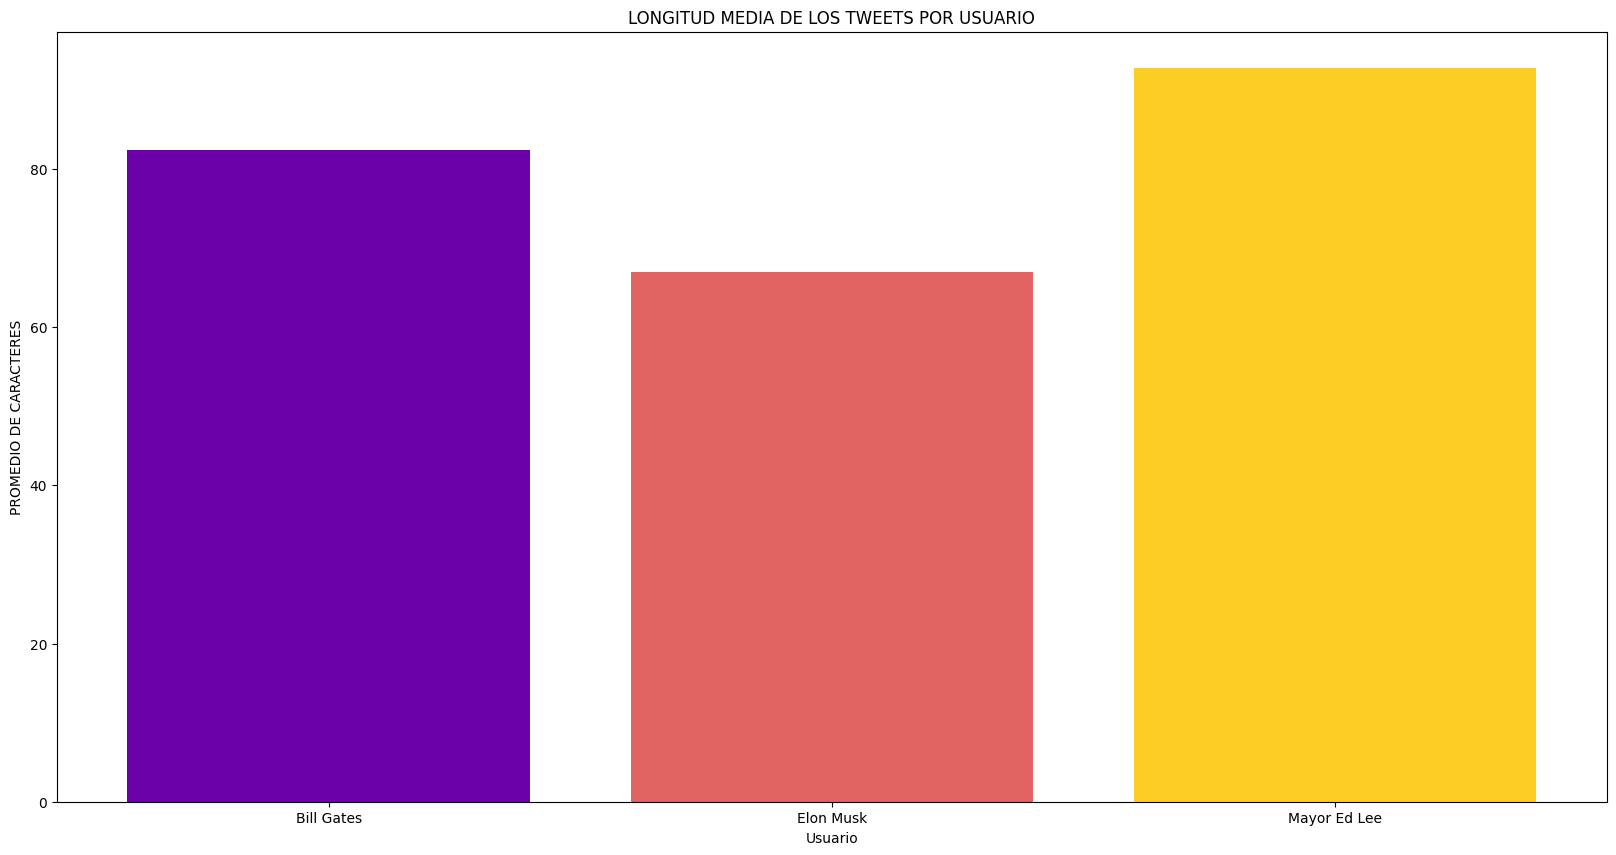

In [21]:
longitud_media = {
    "Bill Gates": dGates["Clean_Content"].str.len().mean(),
    "Elon Musk": dMusk["Clean_Content"].str.len().mean(),
    "Mayor Ed Lee": dLee["Clean_Content"].str.len().mean()
}

df_longitud = pd.DataFrame(list(longitud_media.items()), columns=["Usuario", "Longitud Media"])

print("Longitud media de los tweets por usuario:")
display(df_longitud)

plt.figure(figsize=(20, 10))

colores_plasma = plt.cm.plasma([0.2, 0.6, 0.9])

barras = plt.bar(df_longitud["Usuario"], df_longitud["Longitud Media"], color=colores_plasma)

plt.title("LONGITUD MEDIA DE LOS TWEETS POR USUARIO")
plt.xlabel("Usuario")
plt.ylabel("PROMEDIO DE CARACTERES")
plt.show()

# 4.6 HACER WORKCLOUDS DE LAS PALABRAS DISTINTAS QUE USA CADA USUARIO

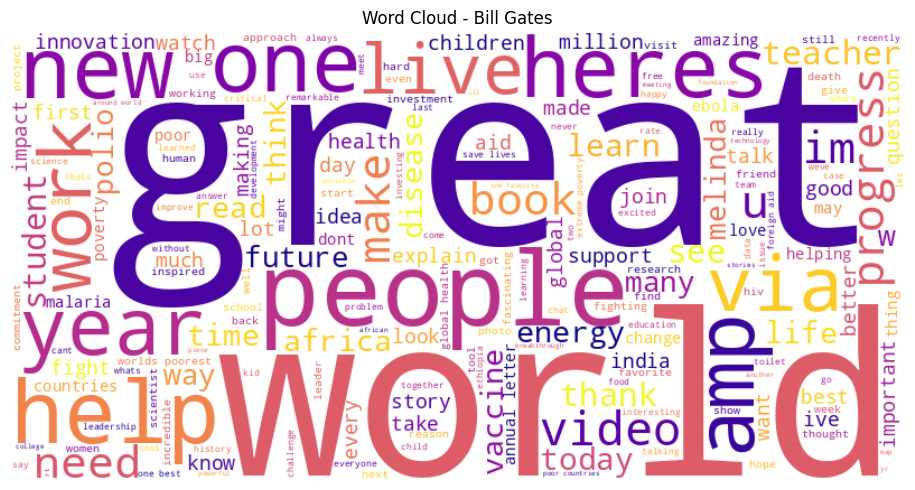

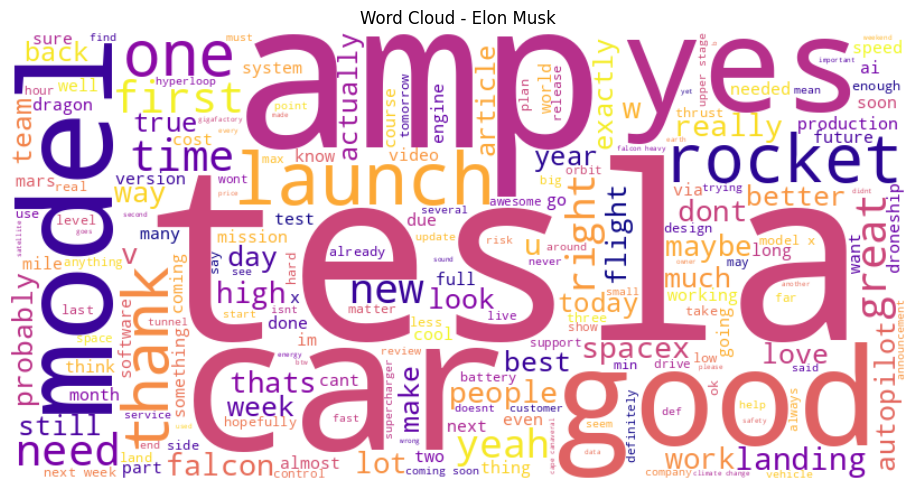

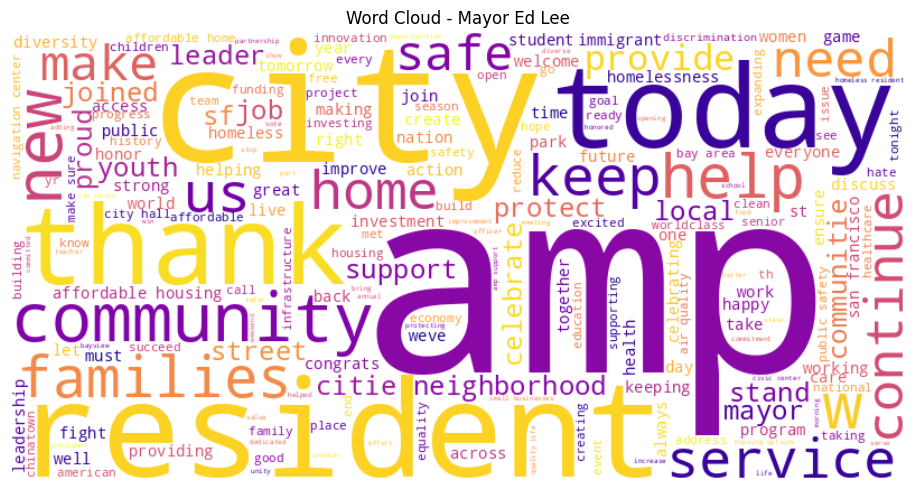

In [23]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

usuarios_textos = {
    "Bill Gates": " ".join(dGates["Final_Content"].astype(str)),
    "Elon Musk": " ".join(dMusk["Final_Content"].astype(str)),
    "Mayor Ed Lee": " ".join(dLee["Final_Content"].astype(str))
}

for usuario, texto_completo in usuarios_textos.items():
    wordcloud = WordCloud(
        width=800, 
        height=400, 
        background_color="white", 
        colormap="plasma"
    ).generate(texto_completo)
    
 
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.title(f"Word Cloud - {usuario}")
    plt.axis("off")
    plt.tight_layout()
    plt.show()